Task 3

Apply supervised learning models like Linear Regression and Decision Tree on the Titanic dataset after performing data cleaning and feature engineering


Data Preprocessing: Use the cleaned and feature-engineered dataset.
Model Training: Train both a Linear Regression model and a Decision Tree model on the training data.
Model Evaluation: Evaluate both models using metrics like Mean Squared Error (MSE), R² score for regression tasks, and accuracy for classification tasks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Load Titanic Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train1.csv to train1.csv


In [ ]:
df = pd.read_csv("train1.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [ ]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin     

Data Cleaning

In [ ]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill missing Cabin
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [ ]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Remove Duplicate Records

In [ ]:
print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (891, 12)
Shape after removing duplicates: (891, 12)


Feature Engineering

1)Create Title

In [ ]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print(df[['Name', 'Title']].head())

                                                Name Title
0                            Braund, Mr. Owen Harris    Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs
2                             Heikkinen, Miss. Laina  Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs
4                           Allen, Mr. William Henry    Mr


2)Create Family Size

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(df[['SibSp', 'Parch', 'FamilySize']].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


3)Create Age Group

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle_Age', 'Senior']
)

print(df[['Age', 'AgeGroup']].head())

    Age    AgeGroup
0  22.0       Adult
1  38.0  Middle_Age
2  26.0       Adult
3  35.0       Adult
4  35.0       Adult


Selecting Features

In [ ]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'FamilySize'
]

X = df[features]
y = df['Survived']

Convert Categorical Data to Numerical

In [ ]:
X = pd.get_dummies(
    X,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

print(X.head())
print("\nFeatures:")
print(X.columns)

   Pclass   Age  SibSp  Parch     Fare  FamilySize  Sex_male  Embarked_Q  \
0       3  22.0      1      0   7.2500           2      True       False   
1       1  38.0      1      0  71.2833           2     False       False   
2       3  26.0      0      0   7.9250           1     False       False   
3       1  35.0      1      0  53.1000           2     False       False   
4       3  35.0      0      0   8.0500           1      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  

Features:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 9)
Testing data: (179, 9)


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression Model

In [ ]:
# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression predictions:")
print(y_pred_lr[:10])

Linear Regression predictions:
[ 0.04829859 -0.01914074  0.18232401 -0.05441057  0.66563911  0.50913632
  0.71894561  0.34750419  0.35834152  0.20101936]


Evaluating Linear Regression

In [ ]:
mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_lr)

print("\n----- Linear Regression Results -----")

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


----- Linear Regression Results -----
Mean Squared Error (MSE): 0.15085466122417446
Root Mean Squared Error (RMSE): 0.38840013030916254
R² Score: 0.3631707246002933


Decision Tree Classifier

In [ ]:
# Create Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

Evaluate Decision Tree

In [ ]:
accuracy = accuracy_score(y_test, y_pred_dt)

precision = precision_score(y_test, y_pred_dt)

recall = recall_score(y_test, y_pred_dt)

f1 = f1_score(y_test, y_pred_dt)

print("\n----- Decision Tree Results -----")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


----- Decision Tree Results -----
Accuracy : 0.7597765363128491
Precision: 0.7407407407407407
Recall   : 0.5797101449275363
F1 Score : 0.6504065040650406


Confusion Matrix


Confusion Matrix:
[[96 14]
 [29 40]]


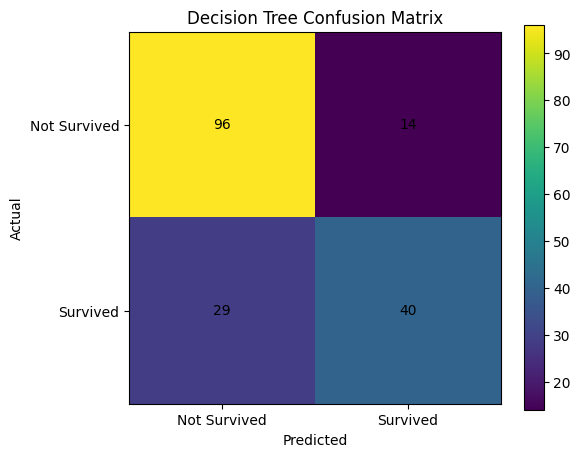

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.yticks([0, 1], ['Not Survived', 'Survived'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.show()

Classification Report

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.74      0.58      0.65        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.76      0.76      0.75       179



Comparing the Models

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree'
    ],

    'MSE': [
        mse,
        mean_squared_error(y_test, y_pred_dt)
    ],

    'R2 Score': [
        r2,
        r2_score(y_test, y_pred_dt)
    ],

    'Accuracy': [
        accuracy_score(y_test, np.round(y_pred_lr)),
        accuracy_score(y_test, y_pred_dt)
    ]
})

comparison = comparison.round(4)

print("\n========== MODEL COMPARISON ==========")
print(comparison)


========== MODEL COMPARISON ==========
               Model     MSE  R2 Score  Accuracy
0  Linear Regression  0.1509    0.3632    0.8101
1      Decision Tree  0.2402   -0.0141    0.7598


Visualize Actual vs Predicted — Linear Regression

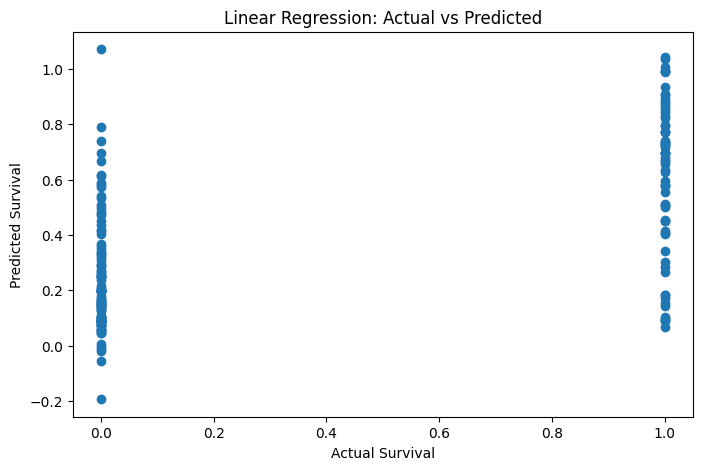

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_lr
)

plt.xlabel("Actual Survival")
plt.ylabel("Predicted Survival")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

Complete Code in One Place